# PyContrails Hello World

## Objective

This notebook is the first technical experiment for the robust contrail
routing project.

The objective is to reproduce a minimal end-to-end pycontrails example
and understand how atmospheric conditions and aircraft trajectories
are used to identify contrail-forming conditions.

## Project phase

Phase 0 — Setup and reproduction

In [1]:
import pycontrails

print(pycontrails.__version__)

0.63.3


## 1. Create a synthetic flight

For this initial experiment, we create a simple synthetic aircraft
trajectory. The aircraft travels from longitude 0° to 5° and latitude
50° to 52° while cruising at approximately 11 km altitude.

This is not intended to represent a real flight. It is simply a controlled
trajectory that lets us understand how pycontrails represents flight data.

In [2]:
import numpy as np
import pandas as pd

from pycontrails import Flight

In [3]:
longitude = np.linspace(0, 5, 20)
latitude = np.linspace(50, 52, 20)
altitude = np.full(20, 11_000)

time = pd.date_range(
    "2022-03-01 00:00:00",
    "2022-03-01 01:00:00",
    periods=20,
)

flight = Flight(
    longitude=longitude,
    latitude=latitude,
    altitude=altitude,
    time=time,
    flight_id="hello_world",
)

In [4]:
flight

Flight [4 keys x 20 length, 1 attributes]
	Keys: longitude, latitude, time, altitude
	Attributes:
	time                [2022-03-01 00:00:00, 2022-03-01 01:00:00]
	longitude           [0.0, 5.0]
	latitude            [50.0, 52.0]
	altitude            [11000.0, 11000.0]
	flight_id           hello_world

In [5]:
flight.data.keys()

dict_keys(['longitude', 'latitude', 'time', 'altitude'])

In [6]:
flight["latitude"]

array([50.        , 50.10526316, 50.21052632, 50.31578947, 50.42105263,
       50.52631579, 50.63157895, 50.73684211, 50.84210526, 50.94736842,
       51.05263158, 51.15789474, 51.26315789, 51.36842105, 51.47368421,
       51.57894737, 51.68421053, 51.78947368, 51.89473684, 52.        ])

In [7]:
flight.altitude_ft

array([36089.23884514, 36089.23884514, 36089.23884514, 36089.23884514,
       36089.23884514, 36089.23884514, 36089.23884514, 36089.23884514,
       36089.23884514, 36089.23884514, 36089.23884514, 36089.23884514,
       36089.23884514, 36089.23884514, 36089.23884514, 36089.23884514,
       36089.23884514, 36089.23884514, 36089.23884514, 36089.23884514])

## 2. Load atmospheric data

The aircraft trajectory alone is not sufficient to determine whether
persistent contrails are likely to form.

We therefore combine the flight trajectory with atmospheric conditions.
For this first experiment we use ERA5 reanalysis data through the
pycontrails ARCO ERA5 interface.

The atmospheric variables of interest are air temperature and specific
humidity, which are used by the PCR model to determine the intersection
of the Schmidt-Appleman criterion (SAC) and ice-supersaturated regions
(ISSR).

In [8]:
from pycontrails.datalib.ecmwf import ERA5ARCO

era5 = ERA5ARCO(
    time=("2022-03-01T00", "2022-03-01T01"),
    variables=["air_temperature", "specific_humidity"],
    pressure_levels=[200, 250, 300],
)

In [9]:
met = era5.open_metdataset()

In [10]:
met.data.data_vars

Data variables:
    air_temperature    (longitude, latitude, level, time) float32 25MB dask.array<chunksize=(1440, 721, 3, 1), meta=np.ndarray>
    specific_humidity  (longitude, latitude, level, time) float32 25MB dask.array<chunksize=(1440, 721, 3, 1), meta=np.ndarray>

In [11]:
met.data.sizes

Frozen({'longitude': 1440, 'latitude': 721, 'level': 3, 'time': 2})

## 3. Persistent Contrail Regions (PCR)

A persistent contrail requires two conditions:

1. The Schmidt–Appleman criterion (SAC) is satisfied.
2. The surrounding atmosphere is ice-supersaturated (ISSR).

The intersection of these conditions defines a Persistent Contrail Region
(PCR).

This experiment evaluates PCR along the synthetic flight trajectory.

In [12]:
from pycontrails.models.pcr import PCR

In [13]:
import inspect
from pycontrails.models.pcr import PCR

print(inspect.signature(PCR))

(met: 'MetDataset | None' = None, params: 'ModelParams | dict[str, Any] | None' = None, **params_kwargs: 'Any') -> 'None'


In [14]:
pcr = PCR(
    met=met,
)

C:\Users\barqb\robust-contrail-routing\.venv\Lib\site-packages\pycontrails\core\models.py:227: UserWarning: 
Met data appears to have originated from ECMWF and no humidity scaling is enabled. For ECMWF data, consider using one of: 
 - 'ConstantHumidityScaling'
 - 'ExponentialBoostHumidityScaling'
 - 'ExponentialBoostLatitudeCorrectionHumidityScaling'
 - 'HistogramMatching'
For example: 
>>> from pycontrails.models.humidity_scaling import ConstantHumidityScaling
>>> PCR(met=met, ..., humidity_scaling=ConstantHumidityScaling(rhi_adj=0.99))
  warnings.warn(


In [15]:
print(pcr)

PCR model
	Persistent contrail regions
	Params: {'copy_source': True, 'interpolation_method': 'linear', 'interpolation_bounds_error': False, 'interpolation_fill_value': nan, 'interpolation_localize': False, 'interpolation_use_indices': False, 'interpolation_q_method': None, 'verify_met': True, 'downselect_met': True, 'met_longitude_buffer': (0.0, 0.0), 'met_latitude_buffer': (0.0, 0.0), 'met_level_buffer': (0.0, 0.0), 'met_time_buffer': (np.timedelta64(0,'h'), np.timedelta64(0,'h')), 'rhi_threshold': 1.0, 'humidity_scaling': None, 'engine_efficiency': 0.3, 'fuel': JetA(fuel_name='Jet A-1', q_fuel=43130000.0, hydrogen_content=13.8, ei_co2=3.159, ei_h2o=1.23, ei_so2=0.0012, ei_sulphates=2.4489795918367345e-05, ei_oc=1.9999999999999998e-05)}



In [16]:
print(pcr.params)

{'copy_source': True, 'interpolation_method': 'linear', 'interpolation_bounds_error': False, 'interpolation_fill_value': nan, 'interpolation_localize': False, 'interpolation_use_indices': False, 'interpolation_q_method': None, 'verify_met': True, 'downselect_met': True, 'met_longitude_buffer': (0.0, 0.0), 'met_latitude_buffer': (0.0, 0.0), 'met_level_buffer': (0.0, 0.0), 'met_time_buffer': (np.timedelta64(0,'h'), np.timedelta64(0,'h')), 'rhi_threshold': 1.0, 'humidity_scaling': None, 'engine_efficiency': 0.3, 'fuel': JetA(fuel_name='Jet A-1', q_fuel=43130000.0, hydrogen_content=13.8, ei_co2=3.159, ei_h2o=1.23, ei_so2=0.0012, ei_sulphates=2.4489795918367345e-05, ei_oc=1.9999999999999998e-05)}


## 4. Evaluate persistent contrail regions along the flight

The PCR model combines the aircraft trajectory with the atmospheric
conditions and evaluates whether persistent contrail formation is
possible along the flight path.

In [17]:
pcr_flight = pcr.eval(source=flight)

C:\Users\barqb\robust-contrail-routing\.venv\Lib\site-packages\pycontrails\core\models.py:227: UserWarning: 
Met data appears to have originated from ECMWF and no humidity scaling is enabled. For ECMWF data, consider using one of: 
 - 'ConstantHumidityScaling'
 - 'ExponentialBoostHumidityScaling'
 - 'ExponentialBoostLatitudeCorrectionHumidityScaling'
 - 'HistogramMatching'
For example: 
>>> from pycontrails.models.humidity_scaling import ConstantHumidityScaling
>>> ISSR(met=met, ..., humidity_scaling=ConstantHumidityScaling(rhi_adj=0.99))
  warnings.warn(


In [18]:
pcr_flight

Flight [15 keys x 20 length, 6 attributes]
	Keys: longitude, latitude, time, altitude, flight_id, ..., pcr
	Attributes:
	time                [2022-03-01 00:00:00, 2022-03-01 01:00:00]
	longitude           [0.0, 5.0]
	latitude            [50.0, 52.0]
	altitude            [11000.0, 11000.0]
	flight_id           hello_world
	met_source_provider ECMWF
	met_source_dataset  ERA5
	met_source_product  reanalysis
	pycontrails_version 0.63.3
	engine_efficiency   0.3

In [19]:
pcr_flight.data.keys()

dict_keys(['longitude', 'latitude', 'time', 'altitude', 'flight_id', 'air_pressure', 'air_temperature', 'specific_humidity', 'issr', 'G', 'T_sat_liquid', 'rh', 'rh_critical_sac', 'sac', 'pcr'])

In [20]:
pcr_flight.data

{'longitude': array([0.        , 0.26315789, 0.52631579, 0.78947368, 1.05263158,
        1.31578947, 1.57894737, 1.84210526, 2.10526316, 2.36842105,
        2.63157895, 2.89473684, 3.15789474, 3.42105263, 3.68421053,
        3.94736842, 4.21052632, 4.47368421, 4.73684211, 5.        ]),
 'latitude': array([50.        , 50.10526316, 50.21052632, 50.31578947, 50.42105263,
        50.52631579, 50.63157895, 50.73684211, 50.84210526, 50.94736842,
        51.05263158, 51.15789474, 51.26315789, 51.36842105, 51.47368421,
        51.57894737, 51.68421053, 51.78947368, 51.89473684, 52.        ]),
 'time': array(['2022-03-01T00:00:00.000000000', '2022-03-01T00:03:09.473684000',
        '2022-03-01T00:06:18.947368000', '2022-03-01T00:09:28.421052000',
        '2022-03-01T00:12:37.894736000', '2022-03-01T00:15:47.368421000',
        '2022-03-01T00:18:56.842105000', '2022-03-01T00:22:06.315789000',
        '2022-03-01T00:25:15.789473000', '2022-03-01T00:28:25.263157000',
        '2022-03-01T00:31:34.

In [21]:
type(pcr_flight)

pycontrails.core.flight.Flight

In [22]:
results = pd.DataFrame({
    "time": pcr_flight.data["time"],
    "sac": pcr_flight.data["sac"],
    "issr": pcr_flight.data["issr"],
    "pcr": pcr_flight.data["pcr"],
})

results

,time,sac,issr,pcr
0,2022-03-01 00:00:00.000000,1.0,0.0,0.0
1,2022-03-01 00:03:09.473684,1.0,0.0,0.0
2,2022-03-01 00:06:18.947368,1.0,0.0,0.0
3,2022-03-01 00:09:28.421052,1.0,0.0,0.0
4,2022-03-01 00:12:37.894736,1.0,0.0,0.0
5,2022-03-01 00:15:47.368421,1.0,0.0,0.0
6,2022-03-01 00:18:56.842105,1.0,0.0,0.0
7,2022-03-01 00:22:06.315789,1.0,0.0,0.0
8,2022-03-01 00:25:15.789473,1.0,0.0,0.0
9,2022-03-01 00:28:25.263157,1.0,0.0,0.0


In [23]:
print("SAC:", pcr_flight.data["sac"].sum())
print("ISSR:", pcr_flight.data["issr"].sum())
print("PCR:", pcr_flight.data["pcr"].sum())

SAC: 20.0
ISSR: 0.0
PCR: 0.0


In [24]:
results = pd.DataFrame({
    "time": pcr_flight.data["time"],
    "temperature": pcr_flight.data["air_temperature"],
    "pressure": pcr_flight.data["air_pressure"],
    "RH": pcr_flight.data["rh"],
    "critical_RH": pcr_flight.data["rh_critical_sac"],
    "SAC": pcr_flight.data["sac"],
    "ISSR": pcr_flight.data["issr"],
    "PCR": pcr_flight.data["pcr"],
})

results

,time,temperature,pressure,RH,critical_RH,SAC,ISSR,PCR
0,2022-03-01 00:00:00.000000,213.216385,22631.70091,0.386965,0.0,1.0,0.0,0.0
1,2022-03-01 00:03:09.473684,213.042496,22631.70091,0.393818,0.0,1.0,0.0,0.0
2,2022-03-01 00:06:18.947368,212.874176,22631.70091,0.409457,0.0,1.0,0.0,0.0
3,2022-03-01 00:09:28.421052,212.760574,22631.70091,0.427309,0.0,1.0,0.0,0.0
4,2022-03-01 00:12:37.894736,212.662323,22631.70091,0.439702,0.0,1.0,0.0,0.0
5,2022-03-01 00:15:47.368421,212.570633,22631.70091,0.448597,0.0,1.0,0.0,0.0
6,2022-03-01 00:18:56.842105,212.426346,22631.70091,0.456876,0.0,1.0,0.0,0.0
7,2022-03-01 00:22:06.315789,212.264496,22631.70091,0.470448,0.0,1.0,0.0,0.0
8,2022-03-01 00:25:15.789473,212.094284,22631.70091,0.485195,0.0,1.0,0.0,0.0
9,2022-03-01 00:28:25.263157,211.969879,22631.70091,0.499295,0.0,1.0,0.0,0.0


In [25]:
print("Minimum RH:", results["RH"].min())
print("Maximum RH:", results["RH"].max())
print("Mean RH:", results["RH"].mean())

Minimum RH: 0.386965107970179
Maximum RH: 0.501083290788572
Mean RH: 0.44510076115468966


## Session 2 — Spatial variation in persistent contrail conditions

The first experiment evaluated a single synthetic flight under ERA5
meteorological conditions.

This session extends the experiment to a longer flight and a larger
meteorological domain in order to investigate how persistent contrail
conditions vary along a trajectory.

In [26]:
from pycontrails.datalib.ecmwf import ERA5ARCO

era5_session2 = ERA5ARCO(
    time=("2022-03-01T00", "2022-03-01T06"),
    variables=["air_temperature", "specific_humidity"],
    pressure_levels=[200, 225, 250, 275, 300],
)

In [27]:
met_session2 = era5_session2.open_metdataset()

In [28]:
from pycontrails.datalib.ecmwf import ERA5ARCO

era5_session2 = ERA5ARCO(
    time=("2022-03-01T00", "2022-03-01T06"),
    variables=["air_temperature", "specific_humidity"],
    pressure_levels=[200, 225, 250, 275, 300],
)

In [29]:
from pycontrails.datalib.ecmwf import ERA5ARCO

In [30]:
print("Opening Session 2 ERA5 dataset...")

met_session2 = era5_session2.open_metdataset()

print("Session 2 ERA5 dataset loaded.")

Opening Session 2 ERA5 dataset...
Session 2 ERA5 dataset loaded.


In [31]:
print(met_session2.data)
print()
print("Dataset dimensions:")
print(met_session2.data.sizes)

<xarray.Dataset> Size: 291MB
Dimensions:            (longitude: 1440, latitude: 721, level: 5, time: 7)
Coordinates:
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
  * latitude           (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.75 90.0
  * level              (level) float64 40B 200.0 225.0 250.0 275.0 300.0
    air_pressure       (level) float32 20B dask.array<chunksize=(5,), meta=np.ndarray>
    altitude           (level) float32 20B dask.array<chunksize=(5,), meta=np.ndarray>
  * time               (time) datetime64[ns] 56B 2022-03-01 ... 2022-03-01T06...
Data variables:
    air_temperature    (longitude, latitude, level, time) float32 145MB dask.array<chunksize=(1440, 721, 5, 1), meta=np.ndarray>
    specific_humidity  (longitude, latitude, level, time) float32 145MB dask.array<chunksize=(1440, 721, 5, 1), meta=np.ndarray>
Attributes:
    last_updated:           2026-09-15 01:46:55.652191+00:00
    valid_time_start:       1940-01-01
    valid_t

In [32]:
print("Temperature range:")
print(met_session2.data["air_temperature"].min().compute().item(),
      "to",
      met_session2.data["air_temperature"].max().compute().item(),
      "K")

print()

print("Specific humidity range:")
print(met_session2.data["specific_humidity"].min().compute().item(),
      "to",
      met_session2.data["specific_humidity"].max().compute().item(),
      "kg/kg")

Temperature range:
196.05126953125 to 250.08084106445312 K

Specific humidity range:
4.911482776037701e-09 to 0.0015835920348763466 kg/kg


In [33]:
import numpy as np
import pandas as pd
from pycontrails import Flight

n_points = 121

time = pd.date_range(
    "2022-03-01 00:00",
    "2022-03-01 06:00",
    periods=n_points,
)

flight_session2 = Flight(
    longitude=np.linspace(-10, 10, n_points),
    latitude=np.linspace(45, 55, n_points),
    altitude=np.full(n_points, 11000.0),
    time=time,
)

flight_session2

Flight [4 keys x 121 length, 0 attributes]
	Keys: longitude, latitude, time, altitude
	Attributes:
	time                [2022-03-01 00:00:00, 2022-03-01 06:00:00]
	longitude           [-10.0, 10.0]
	latitude            [45.0, 55.0]
	altitude            [11000.0, 11000.0]

In [34]:
print("Number of points:", len(flight_session2))

print("Start:")
print({
    key: flight_session2.data[key][0]
    for key in ["longitude", "latitude", "altitude", "time"]
})

print()
print("End:")
print({
    key: flight_session2.data[key][-1]
    for key in ["longitude", "latitude", "altitude", "time"]
})

Number of points: 121
Start:
{'longitude': np.float64(-10.0), 'latitude': np.float64(45.0), 'altitude': np.float64(11000.0), 'time': np.datetime64('2022-03-01T00:00:00.000000000')}

End:
{'longitude': np.float64(10.0), 'latitude': np.float64(55.0), 'altitude': np.float64(11000.0), 'time': np.datetime64('2022-03-01T06:00:00.000000000')}


In [35]:
pcr_session2 = PCR(
    met=met_session2,
)

C:\Users\barqb\robust-contrail-routing\.venv\Lib\site-packages\pycontrails\core\models.py:227: UserWarning: 
Met data appears to have originated from ECMWF and no humidity scaling is enabled. For ECMWF data, consider using one of: 
 - 'ConstantHumidityScaling'
 - 'ExponentialBoostHumidityScaling'
 - 'ExponentialBoostLatitudeCorrectionHumidityScaling'
 - 'HistogramMatching'
For example: 
>>> from pycontrails.models.humidity_scaling import ConstantHumidityScaling
>>> PCR(met=met, ..., humidity_scaling=ConstantHumidityScaling(rhi_adj=0.99))
  warnings.warn(


In [36]:
pcr_flight_session2 = pcr_session2.eval(
    source=flight_session2
)

print("PCR evaluation complete.")

C:\Users\barqb\robust-contrail-routing\.venv\Lib\site-packages\pycontrails\core\models.py:529: UserWarning: Source flight does not contain `flight_id` data or attr. Adding `flight_id` of 0
  warnings.warn(
C:\Users\barqb\robust-contrail-routing\.venv\Lib\site-packages\pycontrails\core\models.py:227: UserWarning: 
Met data appears to have originated from ECMWF and no humidity scaling is enabled. For ECMWF data, consider using one of: 
 - 'ConstantHumidityScaling'
 - 'ExponentialBoostHumidityScaling'
 - 'ExponentialBoostLatitudeCorrectionHumidityScaling'
 - 'HistogramMatching'
For example: 
>>> from pycontrails.models.humidity_scaling import ConstantHumidityScaling
>>> ISSR(met=met, ..., humidity_scaling=ConstantHumidityScaling(rhi_adj=0.99))
  warnings.warn(


PCR evaluation complete.


In [37]:
results_session2 = pd.DataFrame({
    "time": pcr_flight_session2["time"],
    "longitude": pcr_flight_session2["longitude"],
    "latitude": pcr_flight_session2["latitude"],
    "temperature_K": pcr_flight_session2["air_temperature"],
    "relative_humidity": pcr_flight_session2["rh"],
    "critical_relative_humidity": pcr_flight_session2["rh_critical_sac"],
    "SAC": pcr_flight_session2["sac"],
    "ISSR": pcr_flight_session2["issr"],
    "PCR": pcr_flight_session2["pcr"],
})

results_session2.head()

,time,longitude,latitude,temperature_K,relative_humidity,critical_relative_humidity,SAC,ISSR,PCR
0,2022-03-01 00:00:00,-10.000000,45.000000,211.477188,0.606994,0.0,1.0,1.0,1.0
1,2022-03-01 00:03:00,-9.833333,45.083333,211.371338,0.604835,0.0,1.0,1.0,1.0
2,2022-03-01 00:06:00,-9.666667,45.166667,211.227554,0.608579,0.0,1.0,1.0,1.0
3,2022-03-01 00:09:00,-9.500000,45.250000,211.078918,0.615010,0.0,1.0,1.0,1.0
4,2022-03-01 00:12:00,-9.333333,45.333333,211.052475,0.610527,0.0,1.0,1.0,1.0


In [38]:
print("PCR range:")
print(results_session2["PCR"].min(), "to", results_session2["PCR"].max())

print()
print("ISSR points:", results_session2["ISSR"].sum())
print("PCR points:", (results_session2["PCR"] > 0).sum())

PCR range:
0.0 to 1.0

ISSR points: 20.0
PCR points: 20


In [39]:
for name in ["met", "pcr", "pcr_flight", "era5_session2", "met_session2", "flight_session2"]:
    print(f"{name:20s}", "present" if name in globals() else "MISSING")

met                  present
pcr                  present
pcr_flight           present
era5_session2        present
met_session2         present
flight_session2      present


In [40]:
from pycontrails.physics import thermo

q = pcr_flight_session2["specific_humidity"]
T = pcr_flight_session2["air_temperature"]
p = pcr_flight_session2["air_pressure"]

results_session2["air_pressure_Pa"] = p
results_session2["rh_recomputed"] = thermo.rh(q, T, p)
results_session2["rhi"] = thermo.rhi(q, T, p)

print("Max |rh - rh_recomputed|:",
      (results_session2["relative_humidity"] - results_session2["rh_recomputed"]).abs().max())
print("RHi/RH ratio range:",
      (results_session2["rhi"] / results_session2["relative_humidity"]).min(), "to",
      (results_session2["rhi"] / results_session2["relative_humidity"]).max())
print("ISSR vs (RHi > 1) disagreements:",
      ((results_session2["ISSR"] > 0) != (results_session2["rhi"] > 1.0)).sum())

results_session2[["time", "temperature_K", "relative_humidity", "rhi", "ISSR", "PCR"]].head()

Max |rh - rh_recomputed|: 0.0
RHi/RH ratio range: 1.742940125922999 to 1.7646474025910996
ISSR vs (RHi > 1) disagreements: 0


,time,temperature_K,relative_humidity,rhi,ISSR,PCR
0,2022-03-01 00:00:00,211.477188,0.606994,1.057955,1.0,1.0
1,2022-03-01 00:03:00,211.371338,0.604835,1.054892,1.0,1.0
2,2022-03-01 00:06:00,211.227554,0.608579,1.062378,1.0,1.0
3,2022-03-01 00:09:00,211.078918,0.615010,1.074604,1.0,1.0
4,2022-03-01 00:12:00,211.052475,0.610527,1.066944,1.0,1.0


In [41]:
print("Points:", len(results_session2))
print(results_session2[["temperature_K", "relative_humidity", "rhi", "SAC", "ISSR", "PCR"]].isna().sum())
print()
print("SAC points: ", int((results_session2["SAC"] > 0).sum()), "/ 121")
print("ISSR points:", int((results_session2["ISSR"] > 0).sum()), "/ 121")
print("PCR points: ", int((results_session2["PCR"] > 0).sum()), "/ 121")

Points: 121
temperature_K        40
relative_humidity    40
rhi                  40
SAC                  40
ISSR                 40
PCR                  40
dtype: int64

SAC points:  81 / 121
ISSR points: 20 / 121
PCR points:  20 / 121


In [42]:
import numpy as np

def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return 2 * R * np.arcsin(np.sqrt(a))

pcr_flag = results_session2["PCR"] > 0
segment_id = (pcr_flag != pcr_flag.shift()).cumsum()

pcr_segments = (
    results_session2[pcr_flag]
    .groupby(segment_id[pcr_flag])
    .agg(
        start_time=("time", "first"),
        end_time=("time", "last"),
        n_points=("PCR", "size"),
        lon_start=("longitude", "first"),
        lat_start=("latitude", "first"),
        lon_end=("longitude", "last"),
        lat_end=("latitude", "last"),
        rhi_min=("rhi", "min"),
        rhi_max=("rhi", "max"),
    )
    .reset_index(drop=True)
)

# Along-track distance: each leg (i -> i+1) is attributed to its starting point
leg_km = haversine_km(
    results_session2["longitude"].values[:-1], results_session2["latitude"].values[:-1],
    results_session2["longitude"].values[1:],  results_session2["latitude"].values[1:],
)
leg_km = np.append(leg_km, 0.0)
results_session2["leg_km"] = leg_km

total_km = leg_km.sum()
pcr_km = leg_km[pcr_flag.values].sum()

print(pcr_segments)
print()
print(f"Total track length:     {total_km:.1f} km")
print(f"Length flagged PCR:     {pcr_km:.1f} km ({100 * pcr_km / total_km:.1f}%)")
print(f"Flight time in PCR:     {pcr_flag.sum() * 3} min of 360 min")

           start_time            end_time  n_points  lon_start  lat_start  \
0 2022-03-01 00:00:00 2022-03-01 00:54:00        19 -10.000000  45.000000   
1 2022-03-01 05:00:00 2022-03-01 05:00:00         1   6.666667  53.333333   

    lon_end    lat_end   rhi_min   rhi_max  
0 -7.000000  46.500000  1.038402  1.205457  
1  6.666667  53.333333  1.004556  1.004556  

Total track length:     1810.4 km
Length flagged PCR:     316.5 km (17.5%)
Flight time in PCR:     60 min of 360 min


In [43]:
rhi = results_session2["rhi"]

print("RHi summary along track:")
print(rhi.describe())
print()
for band in [0.02, 0.05, 0.10]:
    near = ((rhi > 1 - band) & (rhi < 1 + band)).sum()
    print(f"Points with RHi within ±{band:.2f} of 1.0: {near} / 121")
print()
print("Max RHi outside PCR region:", rhi[~pcr_flag].max())
print("Min RHi inside PCR region: ", rhi[pcr_flag].min())

RHi summary along track:
count    81.000000
mean      0.927935
std       0.140074
min       0.668643
25%       0.833939
50%       0.938044
75%       0.992007
max       1.205457
Name: rhi, dtype: float64

Points with RHi within ±0.02 of 1.0: 10 / 121
Points with RHi within ±0.05 of 1.0: 21 / 121
Points with RHi within ±0.10 of 1.0: 47 / 121

Max RHi outside PCR region: 0.9920074461493157
Min RHi inside PCR region:  1.0045564433403353


In [44]:
nan_flag = results_session2["PCR"].isna()

# 1. Contiguous NaN runs
nan_run_id = (nan_flag != nan_flag.shift()).cumsum()
nan_runs = (
    results_session2[nan_flag]
    .assign(idx=results_session2.index[nan_flag])
    .groupby(nan_run_id[nan_flag])
    .agg(first_idx=("idx", "first"), last_idx=("idx", "last"),
         start_time=("time", "first"), end_time=("time", "last"),
         n_points=("PCR", "size"),
         lon_start=("longitude", "first"), lon_end=("longitude", "last"),
         lat_start=("latitude", "first"), lat_end=("latitude", "last"))
    .reset_index(drop=True)
)
print("NaN runs along track:")
print(nan_runs.to_string())
print()

# 2. Are the inputs NaN, or only the outputs?
print("NaN air_pressure:     ", np.isnan(pcr_flight_session2["air_pressure"]).sum())
print("NaN air_temperature:  ", np.isnan(pcr_flight_session2["air_temperature"]).sum())
print("NaN specific_humidity:", np.isnan(pcr_flight_session2["specific_humidity"]).sum())
print()

# 3. What the met dataset actually covers
print("Met times:     ", met_session2.data["time"].values)
print("Met levels:    ", met_session2.data["level"].values)
print("Met lon range: ", float(met_session2.data["longitude"].min()), "to", float(met_session2.data["longitude"].max()))
print("Met lat range: ", float(met_session2.data["latitude"].min()), "to", float(met_session2.data["latitude"].max()))
print()

# 4. Does the met data itself contain NaNs over the flight's region?
sub = met_session2.data["air_temperature"].sel(
    longitude=slice(-10.5, 10.5), latitude=slice(44.5, 55.5)
)
print("NaN count in met air_temperature over flight box, per time:")
print(sub.isnull().sum(dim=["longitude", "latitude", "level"]).compute().to_series())

NaN runs along track:
   first_idx  last_idx          start_time            end_time  n_points  lon_start  lon_end  lat_start  lat_end
0         60        99 2022-03-01 03:00:00 2022-03-01 04:57:00        40        0.0      6.5       50.0    53.25

NaN air_pressure:      0
NaN air_temperature:   40
NaN specific_humidity: 40

Met times:      ['2022-03-01T00:00:00.000000000' '2022-03-01T01:00:00.000000000'
 '2022-03-01T02:00:00.000000000' '2022-03-01T03:00:00.000000000'
 '2022-03-01T04:00:00.000000000' '2022-03-01T05:00:00.000000000'
 '2022-03-01T06:00:00.000000000']
Met levels:     [200. 225. 250. 275. 300.]
Met lon range:  -180.0 to 179.75
Met lat range:  -90.0 to 90.0

NaN count in met air_temperature over flight box, per time:
time
2022-03-01 00:00:00        0
2022-03-01 01:00:00        0
2022-03-01 02:00:00        0
2022-03-01 03:00:00        0
2022-03-01 04:00:00    19125
2022-03-01 05:00:00        0
2022-03-01 06:00:00        0
Name: air_temperature, dtype: int64


In [45]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


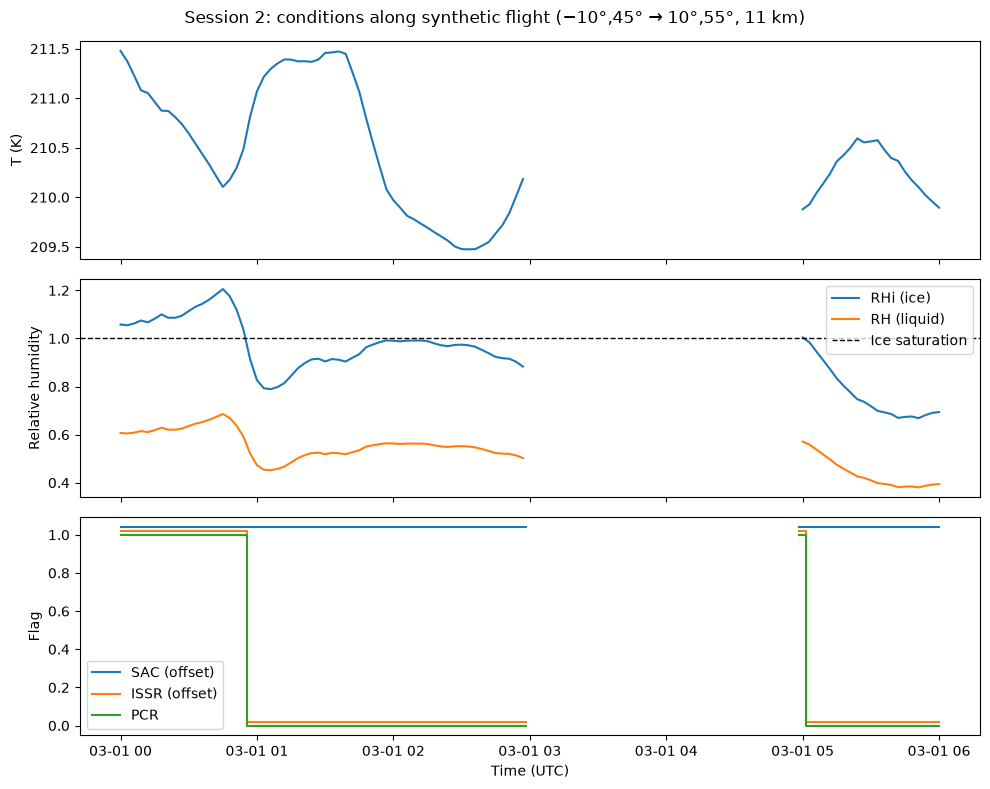

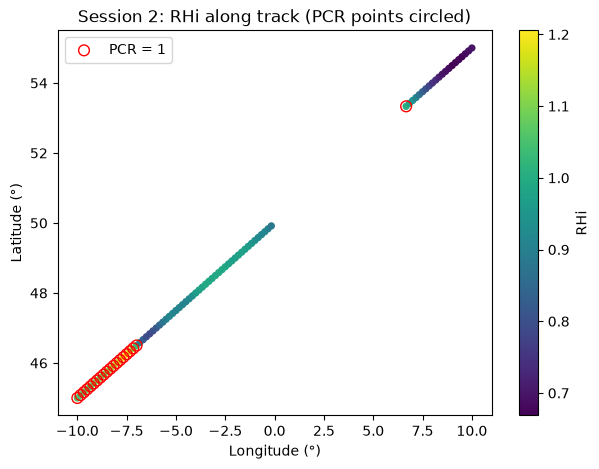

In [46]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(results_session2["time"], results_session2["temperature_K"])
axes[0].set_ylabel("T (K)")

axes[1].plot(results_session2["time"], results_session2["rhi"], label="RHi (ice)")
axes[1].plot(results_session2["time"], results_session2["relative_humidity"], label="RH (liquid)")
axes[1].axhline(1.0, color="k", linestyle="--", linewidth=1, label="Ice saturation")
axes[1].set_ylabel("Relative humidity")
axes[1].legend()

axes[2].step(results_session2["time"], results_session2["SAC"] + 0.04, where="mid", label="SAC (offset)")
axes[2].step(results_session2["time"], results_session2["ISSR"] + 0.02, where="mid", label="ISSR (offset)")
axes[2].step(results_session2["time"], results_session2["PCR"], where="mid", label="PCR")
axes[2].set_ylabel("Flag")
axes[2].set_xlabel("Time (UTC)")
axes[2].legend()

fig.suptitle("Session 2: conditions along synthetic flight (−10°,45° → 10°,55°, 11 km)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(results_session2["longitude"], results_session2["latitude"],
                c=results_session2["rhi"], cmap="viridis", s=18)
ax.scatter(results_session2.loc[pcr_flag, "longitude"],
           results_session2.loc[pcr_flag, "latitude"],
           facecolors="none", edgecolors="red", s=60, label="PCR = 1")
plt.colorbar(sc, label="RHi")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title("Session 2: RHi along track (PCR points circled)")
ax.legend()
plt.show()

In [47]:
from pathlib import Path

results_dir = Path("..") / "results"
results_dir.mkdir(exist_ok=True)

results_session2.to_csv(results_dir / "session2_pcr_along_track.csv", index=False)
pcr_segments.to_csv(results_dir / "session2_pcr_segments.csv", index=False)
print("Saved to:", results_dir.resolve())

Saved to: C:\Users\barqb\robust-contrail-routing\results


### Session 2 results

The 121-point, six-hour synthetic flight (−10°,45° → 10°,55° at 11 km,
2022-03-01 00–06 UTC) was evaluated with PCR on ERA5 (200–300 hPa,
no humidity scaling).

- SAC satisfied at __ / 121 points (critical RH ≈ 0: the air is cold
  enough that SAC is met regardless of humidity)
- ISSR and PCR at 20 / 121 points, in __ contiguous segment(s)
- PCR segment(s): __ to __ UTC, from (__°, __°) to (__°, __°)
- Track length in PCR: __ km of __ km (__%)
- RHi range: __ to __; points within ±0.05 of saturation: __

Unlike Session 1, this trajectory intersects persistent-contrail conditions,
so PCR varies along the route. Because SAC holds everywhere,
**ice supersaturation alone determines where persistent contrails occur**
at this altitude and date.

**Correction to Session 1:** the `rh` output is relative humidity over
liquid water. ISSR is defined using relative humidity over ice (RHi > 1).
RHi is now computed explicitly. Session 1's conclusion (no ISSR) is unchanged.

**Caveat:** ERA5 is known to under-represent ice supersaturation at cruise
levels. This baseline is deliberately unscaled. The number of points near
RHi = 1 indicates how sensitive the result is to humidity uncertainty, which
will be examined in a later session.

In [48]:
results_session2_gap = results_session2.copy()
print("Saved copy:", results_session2_gap.shape, "| NaN PCR:", results_session2_gap["PCR"].isna().sum())

Saved copy: (121, 13) | NaN PCR: 40


In [49]:
t04 = met_session2.data.sel(time="2022-03-01T04")

for var in ["air_temperature", "specific_humidity"]:
    frac = float(t04[var].isnull().mean().compute())
    print(f"{var:20s} NaN fraction at 04:00 (global): {frac:.4f}")

air_temperature      NaN fraction at 04:00 (global): 1.0000
specific_humidity    NaN fraction at 04:00 (global): 1.0000


In [50]:
from pycontrails.datalib.ecmwf import ERA5ARCO

era5_check_04 = ERA5ARCO(
    time="2022-03-01T04",
    variables=["air_temperature", "specific_humidity"],
    pressure_levels=[200, 225, 250, 275, 300],
    cachestore=None,
)
met_check_04 = era5_check_04.open_metdataset()

box = met_check_04.data.sel(longitude=slice(-10.5, 10.5), latitude=slice(44.5, 55.5))
for var in ["air_temperature", "specific_humidity"]:
    print(f"{var:20s} NaN count over flight box at 04:00 (fresh read):",
          int(box[var].isnull().sum().compute()))

air_temperature      NaN count over flight box at 04:00 (fresh read): 0
specific_humidity    NaN count over flight box at 04:00 (fresh read): 0


In [52]:
era5_session2 = ERA5ARCO(
    time=("2022-03-01T00", "2022-03-01T06"),
    variables=["air_temperature", "specific_humidity"],
    pressure_levels=[200, 225, 250, 275, 300],
    cachestore=None,
)
met_session2 = era5_session2.open_metdataset()

box = met_session2.data.sel(longitude=slice(-10.5, 10.5), latitude=slice(44.5, 55.5))
nan_per_time = (
    box[["air_temperature", "specific_humidity"]]
    .isnull()
    .sum(dim=["longitude", "latitude", "level"])
    .compute()
    .to_dataframe()
)
print(nan_per_time)
assert int(nan_per_time.values.sum()) == 0, "Met data over the flight box still contains NaNs"
print("Met data over flight box is complete.")

MemoryError: Unable to allocate 1.06 GiB for an array with shape (1038240, 137) and data type float64

In [53]:
import gc
from pathlib import Path

results_dir = Path("..") / "results"
results_dir.mkdir(exist_ok=True)
results_session2_gap.to_csv(results_dir / "session2_pcr_along_track_gap_0400UTC.csv", index=False)

for name in ["met_session2", "era5_session2", "met_check_04", "era5_check_04", "box", "t04", "sub"]:
    if name in globals():
        del globals()[name]
gc.collect()
print("Saved gapped results and released met objects.")

Saved gapped results and released met objects.


In [54]:
import pandas as pd
from pycontrails.datalib.ecmwf import ERA5ARCO

era5_session2 = ERA5ARCO(
    time=("2022-03-01T00", "2022-03-01T06"),
    variables=["air_temperature", "specific_humidity"],
    pressure_levels=[200, 225, 250, 275, 300],
)   # default cachestore, as in the original load

cs = era5_session2.cachestore
print("Cache store:", type(cs).__name__)
print("Cache dir:  ", getattr(cs, "cache_dir", "attribute not found"))

for hour in ["03", "04", "05"]:
    try:
        path = era5_session2.create_cachepath(pd.Timestamp(f"2022-03-01T{hour}"))
        print(f"{hour}:00 ->", path, "| exists:", Path(path).exists())
    except Exception as e:
        print(f"{hour}:00 -> could not build cache path: {type(e).__name__}: {e}")

Cache store: DiskCacheStore
Cache dir:   C:\Users\barqb\AppData\Local\pycontrails\pycontrails\Cache
03:00 -> C:\Users\barqb\AppData\Local\pycontrails\pycontrails\Cache\arcoera5-ed2bde29bf628093a72e726d61ed5321.nc | exists: True
04:00 -> C:\Users\barqb\AppData\Local\pycontrails\pycontrails\Cache\arcoera5-5b28f26129eb55de82733b9a97b830a1.nc | exists: True
05:00 -> C:\Users\barqb\AppData\Local\pycontrails\pycontrails\Cache\arcoera5-c2e71d9080e84bdde99a79b6faa9132f.nc | exists: True


In [55]:
bad_path = Path(era5_session2.create_cachepath(pd.Timestamp("2022-03-01T04")))
print("Deleting:", bad_path)
bad_path.unlink()
print("Still exists:", bad_path.exists())

Deleting: C:\Users\barqb\AppData\Local\pycontrails\pycontrails\Cache\arcoera5-5b28f26129eb55de82733b9a97b830a1.nc


PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\barqb\\AppData\\Local\\pycontrails\\pycontrails\\Cache\\arcoera5-5b28f26129eb55de82733b9a97b830a1.nc'

In [1]:
from pathlib import Path

bad_path = Path(r"C:\Users\barqb\AppData\Local\pycontrails\pycontrails\Cache\arcoera5-5b28f26129eb55de82733b9a97b830a1.nc")
print("Exists before:", bad_path.exists())
bad_path.unlink()
print("Exists after: ", bad_path.exists())

Exists before: True
Exists after:  False


In [2]:
import numpy as np
import pandas as pd
from pycontrails import Flight
from pycontrails.datalib.ecmwf import ERA5ARCO
from pycontrails.models.pcr import PCR
from pycontrails.physics import thermo

n_points = 121
time = pd.date_range("2022-03-01 00:00", "2022-03-01 06:00", periods=n_points)

flight_session2 = Flight(
    longitude=np.linspace(-10, 10, n_points),
    latitude=np.linspace(45, 55, n_points),
    altitude=np.full(n_points, 11000.0),
    time=time,
)

results_dir = Path("..") / "results"
results_session2_gap = pd.read_csv(
    results_dir / "session2_pcr_along_track_gap_0400UTC.csv", parse_dates=["time"]
)
print("Flight points:", len(flight_session2))
print("Gapped results:", results_session2_gap.shape,
      "| NaN PCR:", results_session2_gap["PCR"].isna().sum())

Flight points: 121
Gapped results: (121, 13) | NaN PCR: 40


In [3]:
era5_session2 = ERA5ARCO(
    time=("2022-03-01T00", "2022-03-01T06"),
    variables=["air_temperature", "specific_humidity"],
    pressure_levels=[200, 225, 250, 275, 300],
)
met_session2 = era5_session2.open_metdataset()

nan_rows = []
for t in met_session2.data["time"].values:
    box_t = met_session2.data.sel(
        time=t, longitude=slice(-10.5, 10.5), latitude=slice(44.5, 55.5)
    )
    nan_rows.append({
        "time": pd.Timestamp(t),
        "air_temperature_nan": int(box_t["air_temperature"].isnull().sum().compute()),
        "specific_humidity_nan": int(box_t["specific_humidity"].isnull().sum().compute()),
    })

nan_per_time = pd.DataFrame(nan_rows)
print(nan_per_time)
assert nan_per_time[["air_temperature_nan", "specific_humidity_nan"]].values.sum() == 0, \
    "Met data over the flight box still contains NaNs"
print("Met data over flight box is complete.")

                 time  air_temperature_nan  specific_humidity_nan
0 2022-03-01 00:00:00                    0                      0
1 2022-03-01 01:00:00                    0                      0
2 2022-03-01 02:00:00                    0                      0
3 2022-03-01 03:00:00                    0                      0
4 2022-03-01 04:00:00                    0                      0
5 2022-03-01 05:00:00                    0                      0
6 2022-03-01 06:00:00                    0                      0
Met data over flight box is complete.


In [4]:
pcr_session2 = PCR(met=met_session2)
pcr_flight_session2 = pcr_session2.eval(source=flight_session2)
print("PCR evaluation complete.")

results_session2 = pd.DataFrame({
    "time": pcr_flight_session2["time"],
    "longitude": pcr_flight_session2["longitude"],
    "latitude": pcr_flight_session2["latitude"],
    "temperature_K": pcr_flight_session2["air_temperature"],
    "relative_humidity": pcr_flight_session2["rh"],
    "critical_relative_humidity": pcr_flight_session2["rh_critical_sac"],
    "SAC": pcr_flight_session2["sac"],
    "ISSR": pcr_flight_session2["issr"],
    "PCR": pcr_flight_session2["pcr"],
})

print("NaN PCR after fix:", results_session2["PCR"].isna().sum())

# Points that were valid before should be identical now
valid_before = results_session2_gap["PCR"].notna()
cols = ["temperature_K", "relative_humidity", "PCR"]
max_diff = (results_session2.loc[valid_before, cols] - results_session2_gap.loc[valid_before, cols]).abs().max()
print("Max difference at previously valid points:")
print(max_diff)

C:\Users\barqb\robust-contrail-routing\.venv\Lib\site-packages\pycontrails\core\models.py:227: UserWarning: 
Met data appears to have originated from ECMWF and no humidity scaling is enabled. For ECMWF data, consider using one of: 
 - 'ConstantHumidityScaling'
 - 'ExponentialBoostHumidityScaling'
 - 'ExponentialBoostLatitudeCorrectionHumidityScaling'
 - 'HistogramMatching'
For example: 
>>> from pycontrails.models.humidity_scaling import ConstantHumidityScaling
>>> PCR(met=met, ..., humidity_scaling=ConstantHumidityScaling(rhi_adj=0.99))
  warnings.warn(
C:\Users\barqb\robust-contrail-routing\.venv\Lib\site-packages\pycontrails\core\models.py:529: UserWarning: Source flight does not contain `flight_id` data or attr. Adding `flight_id` of 0
  warnings.warn(
C:\Users\barqb\robust-contrail-routing\.venv\Lib\site-packages\pycontrails\core\models.py:227: UserWarning: 
Met data appears to have originated from ECMWF and no humidity scaling is enabled. For ECMWF data, consider using one of: 
 

PCR evaluation complete.
NaN PCR after fix: 0
Max difference at previously valid points:
temperature_K        7.006836e-06
relative_humidity    5.551115e-17
PCR                  0.000000e+00
dtype: float64


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
from pycontrails.physics import thermo

# --- RHi and pressure ---
q = pcr_flight_session2["specific_humidity"]
T = pcr_flight_session2["air_temperature"]
p = pcr_flight_session2["air_pressure"]

results_session2["air_pressure_Pa"] = p
results_session2["rh_recomputed"] = thermo.rh(q, T, p)
results_session2["rhi"] = thermo.rhi(q, T, p)

print("=== 1. Humidity checks ===")
print("Max |rh - rh_recomputed|:",
      (results_session2["relative_humidity"] - results_session2["rh_recomputed"]).abs().max())
ratio = results_session2["rhi"] / results_session2["relative_humidity"]
print("RHi/RH ratio range:", ratio.min(), "to", ratio.max())
print("ISSR vs (RHi > 1) disagreements:",
      ((results_session2["ISSR"] > 0) != (results_session2["rhi"] > 1.0)).sum())

# --- NaN check and counts ---
print("\n=== 2. NaN check and counts ===")
print(results_session2[["temperature_K", "relative_humidity", "rhi", "SAC", "ISSR", "PCR"]].isna().sum())
n = len(results_session2)
print("SAC points: ", int((results_session2["SAC"] > 0).sum()), "/", n)
print("ISSR points:", int((results_session2["ISSR"] > 0).sum()), "/", n)
print("PCR points: ", int((results_session2["PCR"] > 0).sum()), "/", n)

# --- Contiguous PCR segments ---
def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return 2 * R * np.arcsin(np.sqrt(a))

pcr_flag = results_session2["PCR"] > 0
segment_id = (pcr_flag != pcr_flag.shift()).cumsum()

pcr_segments = (
    results_session2[pcr_flag]
    .groupby(segment_id[pcr_flag])
    .agg(start_time=("time", "first"), end_time=("time", "last"),
         n_points=("PCR", "size"),
         lon_start=("longitude", "first"), lat_start=("latitude", "first"),
         lon_end=("longitude", "last"), lat_end=("latitude", "last"),
         rhi_min=("rhi", "min"), rhi_max=("rhi", "max"))
    .reset_index(drop=True)
)

leg_km = haversine_km(
    results_session2["longitude"].values[:-1], results_session2["latitude"].values[:-1],
    results_session2["longitude"].values[1:],  results_session2["latitude"].values[1:],
)
results_session2["leg_km"] = np.append(leg_km, 0.0)
total_km = results_session2["leg_km"].sum()
pcr_km = results_session2.loc[pcr_flag, "leg_km"].sum()

print("\n=== 3. PCR segments ===")
print(pcr_segments.to_string())
print(f"Total track length: {total_km:.1f} km")
print(f"Length flagged PCR: {pcr_km:.1f} km ({100 * pcr_km / total_km:.1f}%)")
print(f"Flight time in PCR: {pcr_flag.sum() * 3} min of 360 min")

# --- RHi margins (how close to the threshold) ---
rhi = results_session2["rhi"]
print("\n=== 4. RHi margins ===")
print(rhi.describe())
for band in [0.02, 0.05, 0.10]:
    print(f"Points with RHi within ±{band:.2f} of 1.0: {((rhi > 1 - band) & (rhi < 1 + band)).sum()} / {n}")
print("Max RHi outside PCR region:", rhi[~pcr_flag].max())
print("Min RHi inside PCR region: ", rhi[pcr_flag].min())

# --- Save ---
results_dir = Path("..") / "results"
results_dir.mkdir(exist_ok=True)
results_session2.to_csv(results_dir / "session2_pcr_along_track.csv", index=False)
pcr_segments.to_csv(results_dir / "session2_pcr_segments.csv", index=False)
print("\nSaved CSVs to:", results_dir.resolve())

=== 1. Humidity checks ===
Max |rh - rh_recomputed|: 0.0
RHi/RH ratio range: 1.742940125922999 to 1.7646474025910996
ISSR vs (RHi > 1) disagreements: 0

=== 2. NaN check and counts ===
temperature_K        0
relative_humidity    0
rhi                  0
SAC                  0
ISSR                 0
PCR                  0
dtype: int64
SAC points:  121 / 121
ISSR points: 20 / 121
PCR points:  20 / 121

=== 3. PCR segments ===
           start_time            end_time  n_points  lon_start  lat_start   lon_end    lat_end   rhi_min   rhi_max
0 2022-03-01 00:00:00 2022-03-01 00:54:00        19 -10.000000  45.000000 -7.000000  46.500000  1.038402  1.205457
1 2022-03-01 05:00:00 2022-03-01 05:00:00         1   6.666667  53.333333  6.666667  53.333333  1.004556  1.004556
Total track length: 1810.4 km
Length flagged PCR: 316.5 km (17.5%)
Flight time in PCR: 60 min of 360 min

=== 4. RHi margins ===
count    121.000000
mean       0.929627
std        0.116068
min        0.668643
25%        0.89402

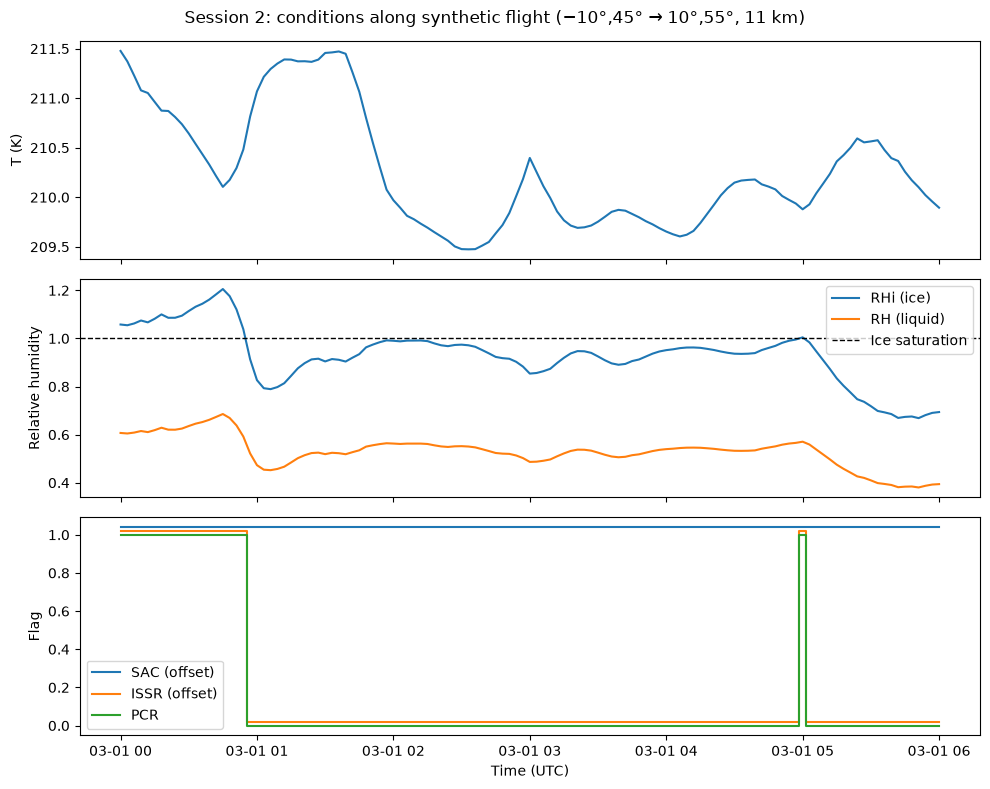

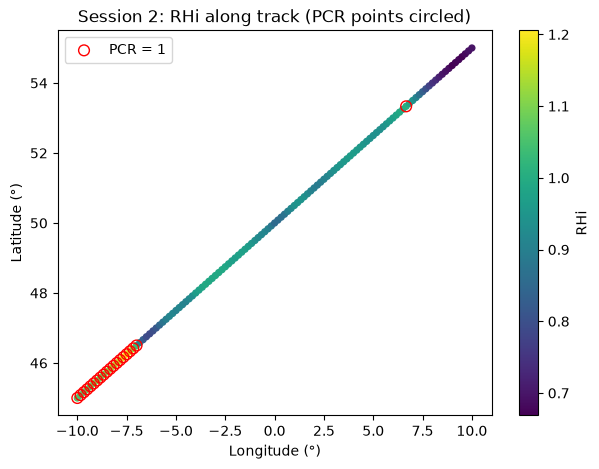

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(results_session2["time"], results_session2["temperature_K"])
axes[0].set_ylabel("T (K)")

axes[1].plot(results_session2["time"], results_session2["rhi"], label="RHi (ice)")
axes[1].plot(results_session2["time"], results_session2["relative_humidity"], label="RH (liquid)")
axes[1].axhline(1.0, color="k", linestyle="--", linewidth=1, label="Ice saturation")
axes[1].set_ylabel("Relative humidity")
axes[1].legend()

axes[2].step(results_session2["time"], results_session2["SAC"] + 0.04, where="mid", label="SAC (offset)")
axes[2].step(results_session2["time"], results_session2["ISSR"] + 0.02, where="mid", label="ISSR (offset)")
axes[2].step(results_session2["time"], results_session2["PCR"], where="mid", label="PCR")
axes[2].set_ylabel("Flag")
axes[2].set_xlabel("Time (UTC)")
axes[2].legend()

fig.suptitle("Session 2: conditions along synthetic flight (−10°,45° → 10°,55°, 11 km)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(results_session2["longitude"], results_session2["latitude"],
                c=results_session2["rhi"], cmap="viridis", s=18)
ax.scatter(results_session2.loc[pcr_flag, "longitude"], results_session2.loc[pcr_flag, "latitude"],
           facecolors="none", edgecolors="red", s=60, label="PCR = 1")
plt.colorbar(sc, label="RHi")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title("Session 2: RHi along track (PCR points circled)")
ax.legend()
plt.show()

### Session 2 results

The 121-point, six-hour synthetic flight (−10°, 45° → 10°, 55° at 11 km,
2022-03-01 00:00–06:00 UTC, one point every 3 minutes) was evaluated with
PCR on ERA5 (200–300 hPa, no humidity scaling).

| Quantity | Value |
|---|---|
| Points evaluated (no missing data) | 121 / 121 |
| SAC satisfied | 121 / 121 |
| ISSR | 20 / 121 |
| PCR | 20 / 121 |
| Track length | 1810.4 km |
| Track length in PCR | 316.5 km (17.5%) |
| Flight time in PCR | 60 of 360 min |
| Along-track temperature | ≈ 209.5–211.5 K |
| Along-track RHi | 0.669 to 1.205 (mean 0.930, median 0.939) |

**Persistent-contrail segments**

| Segment | Time (UTC) | Points | From → to | RHi range |
|---|---|---|---|---|
| 1 | 00:00–00:54 | 19 | (−10.0°, 45.0°) → (−7.0°, 46.5°) | 1.038–1.205 |
| 2 | 05:00 | 1 | (6.67°, 53.33°) | 1.005 |

**Interpretation**

Unlike Session 1, this trajectory crosses persistent-contrail conditions,
so PCR varies along the route. SAC is satisfied at every point (the
critical RH is 0: at ≈210 K the air is cold enough that SAC holds
regardless of humidity). **Ice supersaturation alone therefore determines
where persistent contrails occur** at this altitude and date.

The two segments are very different in character. Segment 1 is a coherent
supersaturated region: RHi rises to 1.205 and then drops sharply below
saturation just before 01:00. Segment 2 is a single point that only just
exceeds saturation (RHi = 1.005). Between them, RHi stays just below 1
for long stretches, peaking at about 0.99 around 02:00 and approaching
1.0 again just before 05:00.

**Sensitivity to the saturation threshold**

The PCR classification is fragile near the threshold:

- The highest RHi outside the PCR region is 0.996; the lowest inside it is 1.005.
- 13 of 121 points lie within ±0.02 of RHi = 1, 35 within ±0.05, and 79 within ±0.10.

A humidity error of only a few percent could therefore add or remove
substantial PCR length. Segment 2 is especially fragile. Segment 1's
core (RHi up to 1.2) is likely more robust. This motivates the later
uncertainty analysis.

**Correction to Session 1**

The `rh` output is relative humidity over **liquid water**; ISSR is
defined by relative humidity over **ice** (RHi > 1). RHi is now computed
explicitly with `pycontrails.physics.thermo.rhi`:

- The recomputed `rh` matches the PCR output exactly (difference 0.0).
- RHi/RH is 1.743–1.765 at these temperatures.
- ISSR agrees with RHi > 1 at every point (0 disagreements).

Session 1's conclusion (no ISSR, no PCR) is unchanged, but it should be
read in terms of RHi rather than `rh`.

**Data-quality note**

The first load of the Session 2 meteorology returned all-NaN temperature
and humidity at 2022-03-01 04:00 UTC. Because PCR interpolates linearly in
time, this made 40 flight points (03:00–04:57) NaN. Counting
`(PCR > 0)` would have silently treated them as "no persistent contrail".
The gap was detected with an explicit NaN check. A fresh read showed the
source data was complete, so the corrupted 04:00 cache file was deleted
and regenerated. After the fix:

- There are 0 missing points.
- Previously valid points are unchanged (PCR identical; temperature
  within 7 × 10⁻⁶ K).

The gapped results are kept in `results/session2_pcr_along_track_gap_0400UTC.csv`
for the record. Re-reading without the cache (`cachestore=None`) was not
viable on this machine: ERA5 ARCO is stored on 137 model levels, and
interpolating global fields in memory exceeded the available RAM. The
disk cache processes one hour at a time.

**Limitations**

- ERA5 is known to under-represent ice supersaturation at cruise levels;
  this baseline is deliberately unscaled (`humidity_scaling=None`).
- The flight samples each location at only one time, so this experiment
  cannot separate spatial from temporal variation. For example, it cannot
  say whether the supersaturated region near (−10°, 45°) persisted
  after 01:00 or moved.
- The flight has a single fixed altitude and a single date.